## Projet : Construction et backtesting d'une stratégie sur options

L'objectif de ce projet est de concevoir, implémenter et backtester une stratégie d'options rigoureuse en utilisant des données de marché réelles.

**1. Sélection et justification de la stratégie**

* **Choix de la stratégie :** Sélectionner une stratégie adéquate pour un sous-jacent donné (actions, taux, matières premières, devises ou titres individuels) et justifier ce choix.
* **Types de stratégies :** Étude possible de stratégies classiques comme le *Bull Call Spread*, le *Straddle* ou l'*Iron Condor*.
* **Codage :** Le gain (*payoff*) de la stratégie doit être codé en utilisant des classes de fonctions.

**2. Pipeline de données**

La préparation des données est une étape cruciale pour assurer la cohérence du backtest.

**Sources de données :**
* **Terminaux professionnels :** Utilisation de **Bloomberg** ou **FactSet**. En cas d'accès aux données temps réel uniquement via Bloomberg, collecter les données à une fréquence plus élevée (ex: deux fois par jour).
* **Alternatives :** Utilisation de l'API **Yahoo Finance** (`yfinance`) si aucun accès professionnel n'est disponible.


**Données requises :**
* **Options :** Primes, prix d'exercice (*strike*), maturité et type. L'utilisation des prix *mid* est suffisante, permettant d'ignorer les *bid/ask* et le *slippage*.
* **Sous-jacent :** Prix *mid* de l'actif sous-jacent.
* **Granularité :** Collecte de l'historique du S&P 500 sur 2 jours avec un pas de temps de 10 minutes pour les données intra-journalières.


**Nettoyage et traitement :**
* Filtrage des anomalies (spreads trop larges, volumes nuls).
* Application de techniques de lissage ou d'interpolation (ex: splines cubiques) pour corriger les irrégularités de la surface de volatilité.



**3. Analyse exploratoire et backtesting**

* **Analyse exploratoire :** Réaliser une exploration des données, notamment par la reconstruction de la surface de volatilité implicite.
* **Implémentation :** Coder l'algorithme de backtesting, d'abord à maturité, puis de manière dynamique.
* **Tests de paramètres :** Tester différentes combinaisons de paramètres tels que le *strike*, la barrière et la maturité.
* **Évaluation :** Procéder à une analyse comparative des performances pour sélectionner la stratégie la plus robuste.

**4. Bonus : Analyse In-Sample et Out-of-Sample**

Pour valider la robustesse du modèle, tester les résultats en divisant les données (ex: période Jan23-Avr23) :

* **In-sample :** Tester la stratégie sur l'ensemble de l'échantillon de données.
* **Out-of-sample :** Entraîner le modèle sur 70 % des données (ex: Jan23-Mar23) et le tester sur les 30 % restants (ex: Avr23).

---

**But du projet :** Aboutir à un travail cohérent et rigoureux, appliquant les méthodologies de codage et de modélisation abordées durant le cours.

# Library

In [1]:
import numpy as np
import pandas as pd
import math
import  matplotlib.pyplot as plt

# I - Simulation of a Geometric Brownian Motion

---

**1. Concepts fondamentaux : Strike ($K$) vs Spot ($S$)**

En finance de marché et pour l'évaluation des produits dérivés, deux variables de prix fondamentales sont systématiquement utilisées:

**Le prix d'exercice (Strike), noté $K$ :** Il représente le prix fixe, déterminé à la conclusion du contrat, auquel le détenteur de l'option a le droit d'acheter (pour un *Call*) ou de vendre (pour un *Put*) l'actif sous-jacent.

**Le prix au comptant (Spot), noté $S_t$ :** Il désigne la valeur de marché de l'actif sous-jacent en temps réel au temps $t$. Cette variable est stochastique (aléatoire) et évolue continuellement au cours du temps.



---

**2. Phénomène du Sourire de Volatilité (*Volatility Smile*)**

Le modèle de référence de Black-Scholes (1973) repose sur l'hypothèse sous-jacente que les rendements de l'actif suivent une loi normale, ce qui implique que la volatilité $\sigma$ devrait être constante pour un même sous-jacent et une même maturité, quels que soient les prix d'exercice $K$.

Cependant, la confrontation empirique aux données de marché met en évidence une structure en forme de « U », appelée **sourire de volatilité**:

**La non-normalité et les queues épaisses (*Fat Tails*)**

Les rendements historiques des marchés financiers exhibent un excès de kurtosis par rapport à la loi normale théorique. La probabilité d'observer des mouvements de prix extrêmes (chocs de marché, krachs) est nettement supérieure à celle prédite par une distribution log-normale.

Pour se couvrir contre ce risque de saut, les agents du marché surévaluent les primes des options très en dehors de la monnaie ($\text{OTM}$) et très dans la monnaie ($\text{ITM}$). La volatilité implicite $\sigma_{\text{implied}}$, obtenue par inversion de la formule de Black-Scholes $C_{\text{marché}} = f(\sigma_{\text{implied}})$, augmente donc à mesure que le ratio de monnaie (*Log-Moneyness*) s'éloigne de zéro:

$$\ln\left(\frac{S_t}{K}\right) \ll 0 \quad \text{ou} \quad \ln\left(\frac{S_t}{K}\right) \gg 0 \implies \sigma_{\text{implied}} \uparrow$$

---

**3. Modélisation Mathématique du Code (Mouvement Brownien Géométrique)**

Le script de simulation s'appuie sur la discrétisation d'une Équation Différentielle Stochastique (EDS) décrivant un **Mouvement Brownien Géométrique** ($\text{GBM}$).

**L'Équation Différentielle Stochastique Continue**

Sous sa forme continue, la dynamique du prix de l'actif $S_t$ sous la mesure de probabilité historique est régie par la formule suivante:

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

Où :

*   $\mu$ représente le paramètre de dérive (*drift*), soit le rendement moyen instantané attendu.


*   $\sigma$ représente la volatilité instantanée du sous-jacent.


*   $W_t$ est un processus de Wiener standard (Mouvement Brownien).



En exprimant cette relation sous forme de rendement relatif (ou taux de croissance instantané), on isole les composantes déterministe et stochastique:

$$\frac{dS_t}{S_t} = \mu dt + \sigma dW_t$$

---

**Discrétisation Temporelle et Schéma d'Euler-Maruyama**

Pour simuler numériquement les trajectoires sur un ordinateur, le temps continu est découpé en intervalles finis de longueur $\Delta t$ (représenté par `dt` dans le code). On applique le schéma d'intégration numérique d'Euler-Maruyama.

**Étape 1 : Modélisation de l'incrément brownien (`dWt`)**

L'incrément du processus de Wiener $\Delta W_t = W_{t+\Delta t} - W_t$ possède la propriété fondamentale suivante:

$$\Delta W_t \sim \mathcal{N}(0, \Delta t) \equiv \sqrt{\Delta t} \cdot \mathcal{N}(0, 1)$$

Dans l'algorithme, cela se traduit par l'échantillonnage d'une variable aléatoire normale centrée réduite multipliée par la racine carrée du pas de temps:


$$\Delta W_t = \text{np.random.normal}(0, \sqrt{\Delta t})$$

**Étape 2 : Évaluation du rendement discret (`dSt`)**

Le rendement sur l'intervalle temporel $[t, t+\Delta t]$ est calculé en combinant la dérive et la composante de diffusion bruitée:

$$\Delta S_{\text{rel}} = \mu \Delta t + \sigma \Delta W_t$$

**Étape 3 : Équation de mise à jour du prix (`self.St *= (1 + dSt)`)**

Par définition, la variation absolue du prix entre deux pas de temps successifs est notée:

$$\Delta S_t = S_{t+\Delta t} - S_t$$

En utilisant l'approximation du rendement relatif $\Delta S_{\text{rel}} \approx \frac{\Delta S_t}{S_t}$ , nous pouvons écrire:

$$S_{t+\Delta t} - S_t = S_t \cdot \Delta S_{\text{rel}}$$

En isolant la valeur future $S_{t+\Delta t}$ par simple manipulation algébrique, on obtient:

$$S_{t+\Delta t} = S_t + S_t \cdot \Delta S_{\text{rel}}$$

Ce qui donne, après factorisation par le prix de la période courante $S_t$:

$$S_{t+\Delta t} = S_t \times (1 + \Delta S_{\text{rel}})$$

C'est cette formulation récursive exacte qui est implémentée via l'opérateur d'affectation compact `*=`. Elle permet de générer de proche en proche l'ensemble des points d'une trajectoire financière discrète.

In [2]:
class gbm:

  def simulate_paths(self):
    while(self.T -self.dt >0):
      dWt = np.random.normal(0, math.sqrt(self.dt))
      dSt = self.mu*self.dt + self.sigma*dWt
      self.St *= (1 + dSt)
      self.prices.append(self.St)
      self.T -= self.dt

  def __init__(self, S0, mu, sigma, T, dt):
    self.St = S0 # Initialize the current price
    self.S0 = S0
    self.mu = mu
    self.sigma = sigma
    self.T = T
    self.dt = dt
    self.prices = [] # Start the price path with the initial price
    self.simulate_paths()

In [3]:
# Parameters
npaths = 1000
S0 = 100
mu = .02
sigma = .15
dt = 1/252
T = 1

In [4]:
# Simulate sample paths
prices_paths = []
for i in range(0, npaths):
  prices_paths.append(gbm(S0, mu, sigma, T, dt).prices)

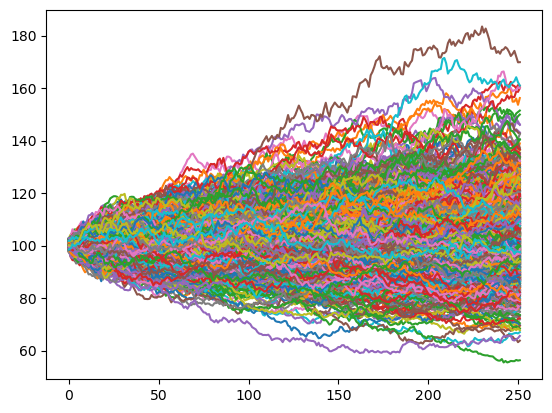

In [5]:
# Plot sample paths
for prices_path in prices_paths:
  plt.plot(prices_path)
plt.show()

# II - **Options Knock-Out Barrier**

## 1) **Up-and-Out Barrier Call Option**
- Une option d'achat barrière up-and-out est un type d'option barrière knock-out dont la valeur devient nulle dès que le cours du sous-jacent dépasse le prix barrière à n'importe quel moment de sa durée de vie, quelle que soit son évolution antérieure. En contrepartie de ce risque de désactivation, cette option est généralement moins coûteuse qu'une option vanilla classique.

- Si le prix du sous-jacent ne dépasse pas le prix barrière, l'option se comporte comme une option d'achat classique (call), c'est-à-dire que le détenteur a le droit, mais non l'obligation, d'exercer son option d'achat au prix d'exercice (strike).

Les options barrière knock-out sont généralement moins chères que les options vanilla car il existe une probabilité d'être exclu de l'option (ce qui rend l'option barrière sans valeur).

- Alternativement, une option barrière peut être construite comme une option knock-in. Contrairement aux knock-outs, une option knock-in n'a aucune valeur tant que le sous-jacent n'atteint pas le prix barrière.

- Les traders peuvent les utiliser comme une option moins coûteuse par rapport aux options plain vanilla. Cependant, l'acheteur d'une option up-and-out ne serait pas protégé si le prix du sous-jacent augmentait au-delà du prix barrière.

$$ C = (S_T-K)^+ \mathbf{1}_{ \begin{Bmatrix} \text{max}\underset{0 \leq t \leq T}\:  S_t < B \end{Bmatrix} } = 
\left\{\begin{matrix}
(S_T-K)^+ \: \: \: \: \text{if max}\underset{0 \leq t \leq T} \:  S_t < B,\\
0 \: \: \: \: \: \: \: \: \: \: \: \: \: \: \text{if max}\underset{0 \leq t \leq T}\:  S_t \ge B 
\end{matrix}\right. $$


In [6]:
class UpAndOutBarrier:
  """
  Continuously monitored up-and-out barrier option

  """
  def __init__(self, K, B):
    self.K = K
    self.B = B
    self.barrier_triggered = False

  def check_barrrier(self, St):
    """
    Update barrier status using the current asset price
    """
    if St > self.B:
      self.barrier_triggered = True

  def calc_payoff(self, St, option_type = "call"):
    """
    Compute payoff at maturity

    Parameters
    ----------

  St : float
      Asset price at maturity (S_T).
  option_type : {"call", "put"}

  Returns
  -------
  float

    """
    if self.barrier_triggered:
      return 0.0

    if option_type == "call":
        return max(St - self.K, 0.0)
    elif option_type == "put":
      return max(self.K - St, 0.0)

    else:
      raise ValueError("option_type must be 'call' or 'put'")

In [7]:
# Affiche les 3 premières trajectoires de la liste
# print(prices_paths[:3])

In [8]:
# Parameters

rf = .01
k = 100
B = 120

option_payoffs = []

for prices_path in prices_paths:
  # Simulate a payoff for each sample path
  bc = UpAndOutBarrier(k, B)
  for price in prices_path:
    bc.check_barrrier(price)
  option_payoffs.append(bc.calc_payoff(prices_path[-1], option_type='call')/(1+rf))
  # We disount the payoff by the rf rate over 1y                   

In [9]:
print(option_payoffs)

[0.0, 0.0, 0.0, 0.0, 0.8283225779245307, 0.0, 7.583389451080833, 0.0, 0.0, 0.0, 0.0, 3.2942523455075317, 16.793972860218524, 0.0, 10.058975795655261, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 11.35359441480305, 0.0, 13.252204469941432, 0.0, 0.0, 0.0, 0.0, 3.2463848388656817, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.670311583343532, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 11.601681249315506, 8.546747631924074, 0.0, 12.306975415382546, 0.0, 0.0, 0.0697838297437168, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1761337327062811, 10.838039964142165, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 18.653747199721067, 0.0, 0.0, 0.0, 0.7195110732082121, 0.0, 0.0, 1.8810310754837682, 0.0, 0.0, 0.0, 4.927240600686389, 10.520400982241526, 3.8145697178154565, 16.787294060272945, 0.0, 0.0, 15.79587733969987, 2.277510315072782, 3.280369649391558, 0.0, 0.0, 2.5937289234562964, 0.0, 0.0, 0.0, 3.2475953071053034, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.032239090971817, 4.3416446701

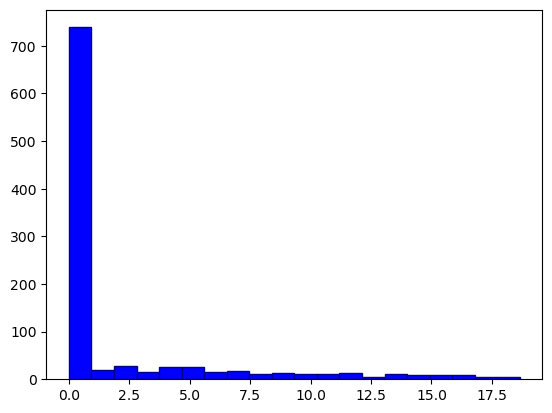

In [10]:
plt.hist(option_payoffs, color = 'blue', edgecolor = 'darkblue', bins = 20)
plt.show()

In [11]:
print(np.average(option_payoffs))

2.007514002760849


## 2) **Down-and-Out Barrier Call Option**

C’est une option dépendante de l’événement où, si le Spot franchit la barrière à la baisse, l’option est désactivée, c.-à-d. qu'elle prend une valeur nulle.
Son fonctionnement est le miroir inversé de l'option Up-and-Out étudiée.

$$ C = (S_T-K)^+ \mathbf{1}_{ \begin{Bmatrix} \text{min}\underset{0 \leq t \leq T}\:  S_t > B \end{Bmatrix} } = 
\left\{\begin{matrix}
(S_T-K)^+ \: \: \: \: \text{if min}\underset{0 \leq t \leq T} \:  S_t > B,\\
0 \: \: \: \: \: \: \: \: \: \: \: \: \: \: \text{if min}\underset{0 \leq t \leq T}\:  S_t \leq B 
\end{matrix}\right. $$

In [12]:
class DownAndOutBarrier:

  def __init__(self, K, B):
    self.K = K
    self.B = B
    self.barrier_triggered = False

  def check_barrrier(self, St):
    if St <= self.B:
      self.barrier_triggered = True

  def calc_payoff(self, St, option_type = "call"):
    if self.barrier_triggered:
      return 0.0

    if option_type == "call":
        return max(St - self.K, 0.0)
    elif option_type == "put":
      return max(self.K - St, 0.0)

    else:
      raise ValueError("option_type must be 'call' or 'put'")

In [13]:
# Parameters
rf = .01
k = 100
B = 90

option_payoffs = []
for prices_path in prices_paths:
  # Simulate a payoff for each sample path
  bc = DownAndOutBarrier(k, B)
  for price in prices_path:
    bc.check_barrrier(price)
  option_payoffs.append(bc.calc_payoff(prices_path[-1], option_type='call')/(1+rf))

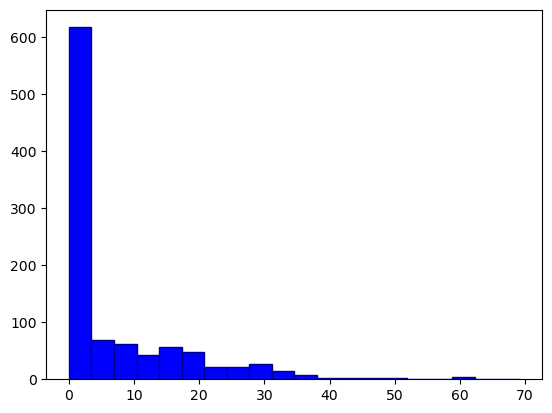

In [14]:
plt.hist(option_payoffs, color = 'blue', edgecolor = 'darkblue', bins = 20)
plt.show()

In [15]:
print(np.average(option_payoffs))

6.630981697046854


## 3) **Up-and-In Barrier Call Option**

Option qui démarre inactivée à 0 et s'active dès que le Spot dépasse la barrière à une certaine maturité. Tant que la barrière n'est pas touchée, le payoff est de 0. Il ne faut pas oublier d'ajouter dans le code **"if not self.barrier_triggered:"**

Contrairement aux options classiques (vanilles) qui existent dès le premier jour, une option Up-and-In naît "endormie" :


*   **État initial** : Au moment de l'achat, l'option est inactivée. Elle ne donne aucun droit à l'acheteur et sa valeur de remboursement théorique est nulle ($0$).
*   **La Barrière ($B$)** : C'est un seuil de prix fixé au-dessus du cours initial de l'actif ($B > S_0$).
*   **L'événement d'activation** : Si, à un moment quelconque pendant la durée de vie du contrat, le cours Spot atteint ou franchit la barrière ($S_t \ge B$), l'option subit un Knock-In. Elle s'active instantanément et se transforme définitivement en une option traditionnelle (un Call ou un Put standard).
*   **L'expiration sans valeur** : Si le cours de l'actif monte, mais sans jamais toucher la barrière $B$ avant l'échéance, l'option meurt inactivée. Le payoff final est de $0$, même si l'actif finit "dans la monnaie" par rapport au strike à la fin de l'année.

$$ C_T=
\begin{cases}
(S_T-K)^+, & \displaystyle \max_{0\le t\le T} S_t \ge B,\\[6pt]
0, & \displaystyle \max_{0\le t\le T} S_t < B.
\end{cases} $$

In [16]:
class UpAndInBarrier:
  def __init__(self, K, B):
    self.K = K
    self.B = B
    self.barrier_triggered = False

  def check_barrrier(self, St):
    # Activate the option in the barrier is touched or crossed
    if St >= self.B:
      self.barrier_triggered = True

  def calc_payoff(self, St, option_type = "call"):
    # No payoff unless the barrier has been triggered
    if not self.barrier_triggered:
      return 0.0

    if option_type == "call":
        return max(St - self.K, 0.0)
    elif option_type == "put":
      return max(self.K - St, 0.0)

    else:
      raise ValueError("option_type must be 'call' or 'put'")

In [17]:
# Parameters
rf = .01
k = 100
B = 90

option_payoffs = []
for prices_path in prices_paths:
  # Simulate a payoff for each sample path
  bc = UpAndInBarrier(k, B)
  for price in prices_path:
    bc.check_barrrier(price)
  option_payoffs.append(bc.calc_payoff(prices_path[-1], option_type='call')/(1+rf))
  # We disount the payoff by the rf rate over 1y

In [18]:
print(option_payoffs)

[20.72735155718951, 0.0, 9.530311859696322, 0.0, 0.8283225779245307, 0.0, 7.583389451080833, 0.0, 16.701927907152623, 0.0, 0.0, 3.2942523455075317, 16.793972860218524, 0.0, 10.058975795655261, 7.832876078571524, 0.0, 0.0, 25.006455842935075, 0.0, 20.771242124683276, 18.333015001894694, 0.0, 3.776683431755638, 6.388356921054496, 11.35359441480305, 34.9429848558954, 13.252204469941432, 27.6467529726554, 0.0, 9.854720173193146, 55.632639484933, 3.2463848388656817, 28.632113215984035, 0.0, 0.0, 0.0, 15.414171765540544, 0.0, 19.279591397102283, 0.0, 6.670311583343532, 0.0, 0.0, 0.0, 0.0, 0.0, 19.090806820447696, 28.900669805417106, 17.11838624032407, 0.0, 0.0, 0.0, 0.0, 11.601681249315506, 8.546747631924074, 0.0, 12.306975415382546, 0.0, 0.0, 0.0697838297437168, 0.0, 17.132782905080088, 15.889233187681933, 22.73510001994184, 0.0, 17.560816433423806, 13.482744797827824, 0.0, 27.80013858236092, 0.0, 24.466618635760145, 0.1761337327062811, 10.838039964142165, 19.632382511423724, 0.0, 21.329066

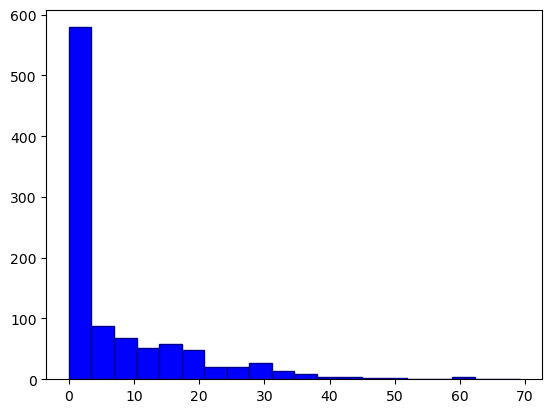

In [19]:
plt.hist(option_payoffs, color = 'blue', edgecolor = 'darkblue', bins = 20)
plt.show()

In [20]:
print(np.average(option_payoffs))

6.974709152839629


## 4) **Down-and-In Barrier Call Option**

Une option **Down-and-In Barrier** (ou option activable à la baisse) est une option exotique dépendante de la trajectoire du sous-jacent. C'est le miroir inversé de l'option Up-and-In : elle démarre inactivée et nécessite une baisse du marché sous un certain seuil pour prendre vie.

Comme toutes les options de type In, elle est caractérisée par une naissance différée :

*   **État initial** : À sa création, l'option est inactivée. L'acheteur ne possède aucun droit d'exercice et sa valeur est nulle ($0$).


*   **La Barrière ($B$)** : C'est un seuil de prix fixé en dessous du cours initial de l'actif ($B < S_0$).L'événement d'activation : Si, à un moment quelconque avant l'échéance, le cours au comptant (Spot) baisse et touche ou franchit cette barrière inférieure ($S_t \le B$), l'option subit un Knock-In. Elle s'active instantanément et définitivement, se transformant en une option classique (Call ou Put standard).


*  **L'expiration sans valeur**: Si le marché reste stable ou progresse sans jamais descendre jusqu'à la barrière $B$, l'option meurt "endormie". Le payoff final est de $0$, même si l'actif finit théoriquement dans la monnaie à l'échéance.

$$ C_T=
\begin{cases}
(S_T-K)^+, & \displaystyle \min_{0\le t\le T} S_t \le B,\\[6pt]
0, & \displaystyle \min_{0\le t\le T} S_t > B.
\end{cases} $$

In [21]:
class DownAndInBarrier:

  def __init__(self, K, B):
    self.K = K
    self.B = B
    self.barrier_triggered = False

  def check_barrrier(self, St):
    if St <= self.B:
      self.barrier_triggered = True

  def calc_payoff(self, St, option_type = "call"):
    if not self.barrier_triggered:
      return 0.0

    if option_type == "call":
        return max(St - self.K, 0.0)
    elif option_type == "put":
      return max(self.K - St, 0.0)

    else:
      raise ValueError("option_type must be 'call' or 'put'")

In [22]:
# Parameters
rf = .01
k = 100
B = 110

option_payoffs = []
for prices_path in prices_paths:
  # Simulate a payoff for each sample path
  bc = DownAndInBarrier(k, B)
  for price in prices_path:
    bc.check_barrrier(price)
  option_payoffs.append(bc.calc_payoff(prices_path[-1], option_type='call')/(1+rf))
  # We disount the payoff by the rf rate over 1y

In [23]:
print(option_payoffs)

[20.72735155718951, 0.0, 9.530311859696322, 0.0, 0.8283225779245307, 0.0, 7.583389451080833, 0.0, 16.701927907152623, 0.0, 0.0, 3.2942523455075317, 16.793972860218524, 0.0, 10.058975795655261, 7.832876078571524, 0.0, 0.0, 25.006455842935075, 0.0, 20.771242124683276, 18.333015001894694, 0.0, 3.776683431755638, 6.388356921054496, 11.35359441480305, 34.9429848558954, 13.252204469941432, 27.6467529726554, 0.0, 9.854720173193146, 55.632639484933, 3.2463848388656817, 28.632113215984035, 0.0, 0.0, 0.0, 15.414171765540544, 0.0, 19.279591397102283, 0.0, 6.670311583343532, 0.0, 0.0, 0.0, 0.0, 0.0, 19.090806820447696, 28.900669805417106, 17.11838624032407, 0.0, 0.0, 0.0, 0.0, 11.601681249315506, 8.546747631924074, 0.0, 12.306975415382546, 0.0, 0.0, 0.0697838297437168, 0.0, 17.132782905080088, 15.889233187681933, 22.73510001994184, 0.0, 17.560816433423806, 13.482744797827824, 0.0, 27.80013858236092, 0.0, 24.466618635760145, 0.1761337327062811, 10.838039964142165, 19.632382511423724, 0.0, 21.329066

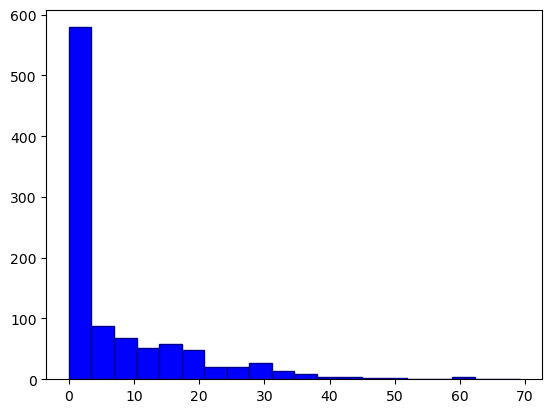

In [24]:
plt.hist(option_payoffs, color = 'blue', edgecolor = 'darkblue', bins = 20)
plt.show()

In [25]:
print(np.average(option_payoffs))

6.974709152839629


## III - Payoff Diagram

In [26]:
pip install opstrat

Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [28]:
import opstrat as op



### Long Call / Short Call



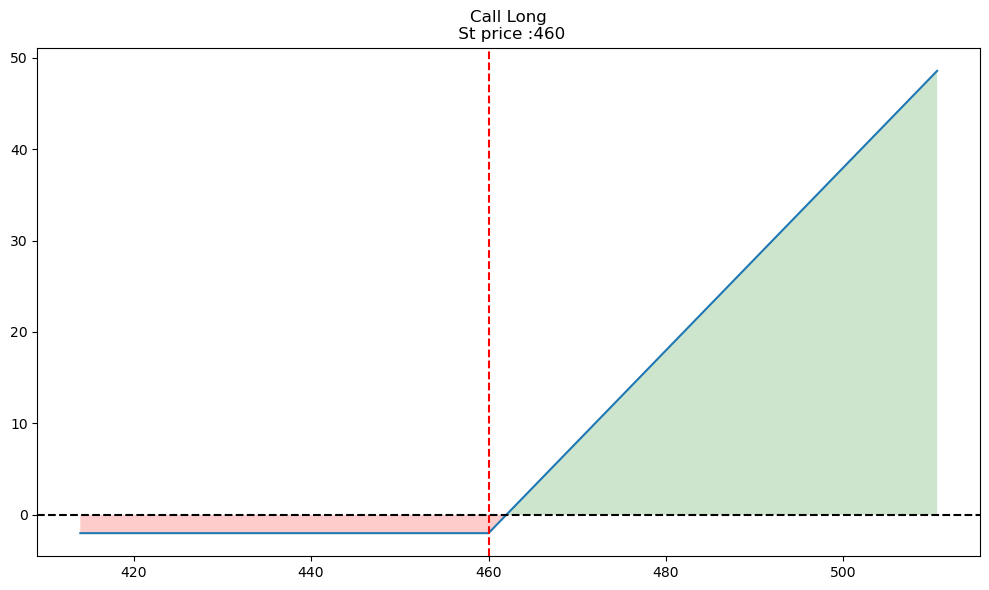

In [29]:
op.single_plotter(spot = 460, strike = 460, op_type='C', tr_type='B', op_pr=2)

Diagramme de gain (payoff) d'une option d'achat (call) à la monnaie (at-the-money) achetée pour une prime de 2, illustrant un risque de perte limité (−2) et un potentiel de gain illimité.

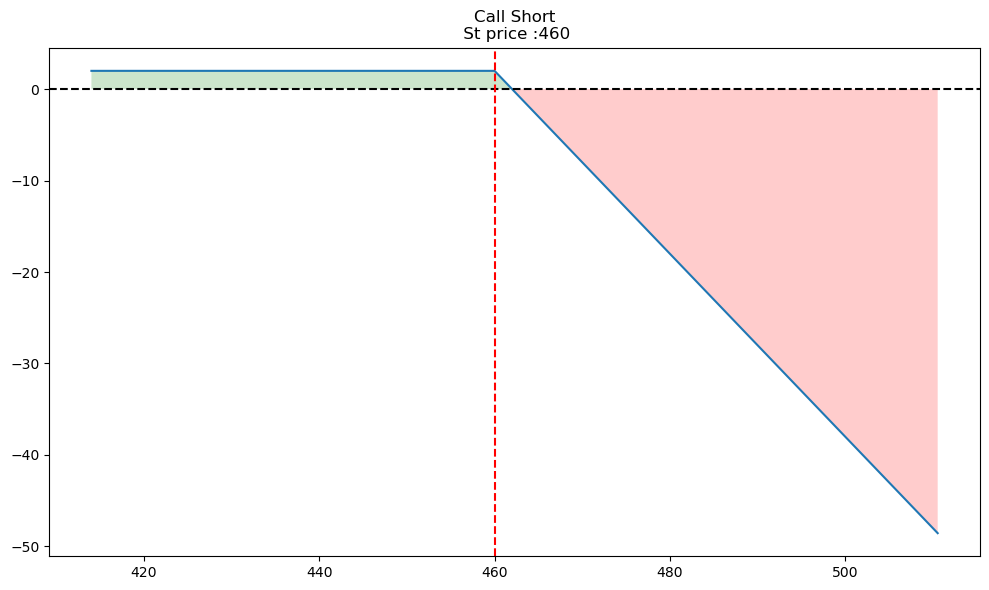

In [30]:
op.single_plotter(spot = 460, strike = 460, op_type='C', tr_type='S', op_pr=2)

### Long Put / Short Put

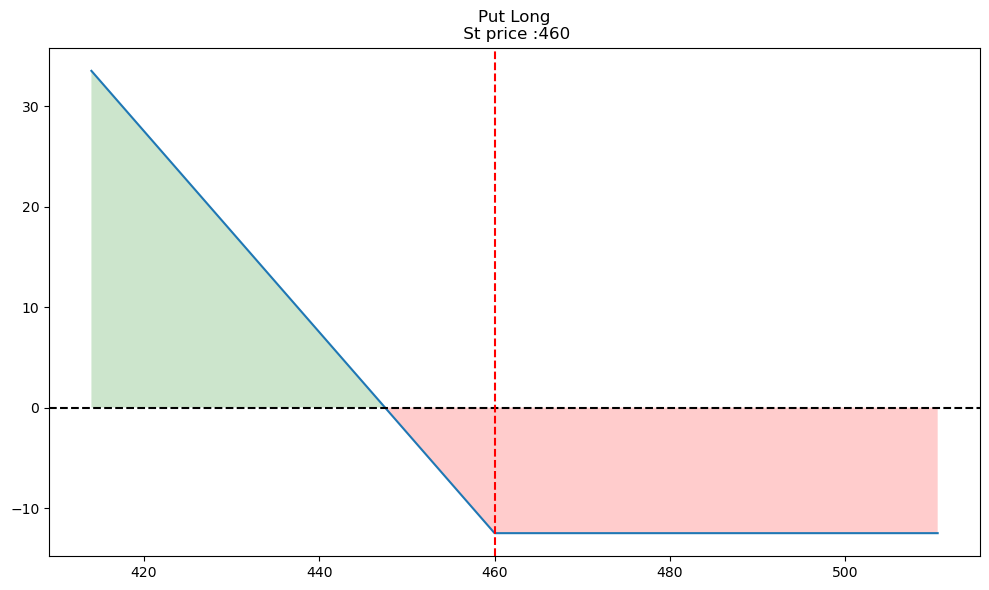

In [31]:
op.single_plotter(spot = 460, strike = 460, op_type='P', tr_type='B', op_pr=12.5)

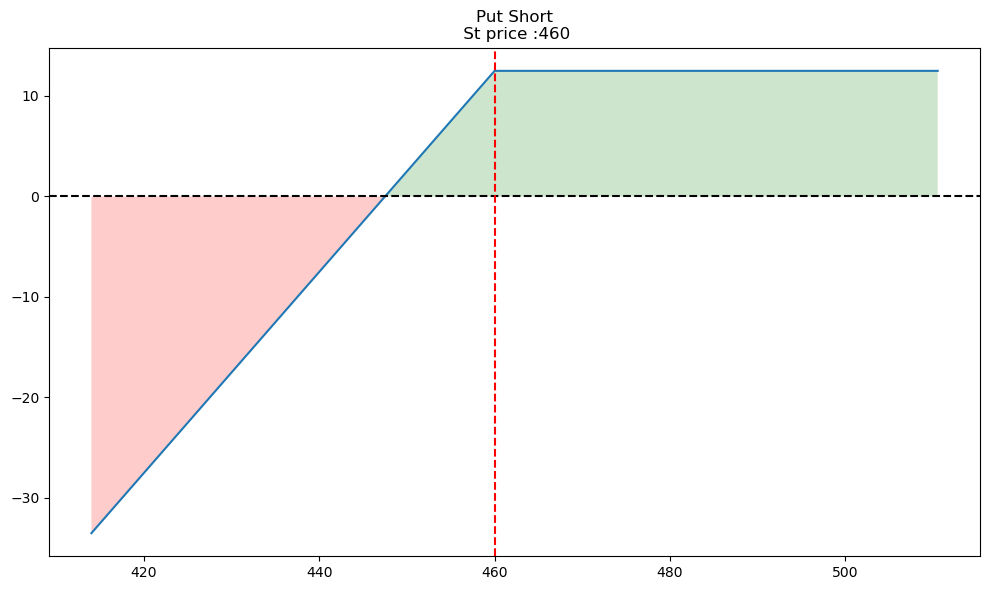

In [32]:
op.single_plotter(spot = 460, strike = 460, op_type='P', tr_type='S', op_pr=12.5)

### Short Strangle





- Un ***short strangle*** consiste à :

* Vendre une option d'achat (*call*) hors de la monnaie (OTM).
* Vendre une option de vente (*put*) hors de la monnaie (OTM).
* Les deux options ont la même date d'échéance.

- Un *short strangle* génère un profit lorsque le prix de l'action sous-jacente évolue dans une fourchette étroite, située entre les points morts (*breakeven points*). La prévision idéale est donc une tendance « neutre ou latérale ». Dans le langage des options, cela est qualifié de « faible volatilité ». Vendre un *strangle* permet d'encaisser deux primes, tandis que l'action doit subir une variation importante avant que vous ne commenciez à perdre de l'argent.


**Structure de la position**

- Vous vendez deux options OTM (Out-of-the-Money) avec la même échéance $T$ :
* Vente du Call (Short Call) : Strike $K_2 > S_0$ . Prime reçue : $C_{OTM}$.
* Vente du Put (Short Put) : Strike $K_1 < S_0$. Prime reçue : $P_{OTM}$.

Le crédit net encaissé à l'ouverture est : $\text{Prime Totale} = C_{OTM} + P_{OTM}$.


**Le Payoff (Gain à l'échéance)**

Le gain final à l'échéance $T$ dépend du cours $S_T$ de l'action :
$$P(S_T) = (C_{OTM} + P_{OTM}) - \max(S_T - K_2, 0) - \max(K_1 - S_T, 0)$$

* **Zone de profit maximal ($K_1 \le S_T \le K_2$) :** Les deux options expirent sans valeur ($\text{max} = 0$).
Gain = Prime Totale.
* **Zone de perte :**
- Si $S_T > K_2$ (hausse forte) : Le Call est exercé. Votre perte est $-(S_T - K_2) + \text{Prime Totale}$.
- Si $S_T < K_1$ (baisse forte) : Le Put est exercé. Votre perte est $-(K_1 - S_T) + \text{Prime Totale}$.

**Les Points Morts (Breakeven Points)**
Ce sont les niveaux de prix où votre gain est nul ($P(S_T) = 0$). Il y en a deux :

* Point mort bas : $K_1 - (\text{Prime Totale})$ 
Si le cours tombe en dessous de ce prix, la perte sur le Put dépasse la prime totale encaissée.

* Point mort haut : $K_2 + (\text{Prime Totale})$ 
Si le cours dépasse ce prix, la perte sur le Call dépasse la prime totale encaissée.

**Interprétation stratégique**
* **"Neutre ou latéral" :** Vous gagnez de l'argent tant que $S_T$ reste dans l'intervalle défini par les points morts.
* **Faible volatilité :** La stratégie bénéficie du Thêta positif (le temps qui passe réduit la valeur des options que vous avez vendues) et du Vega négatif (si la volatilité implicite baisse, vos options perdent de la valeur, ce qui est tout bénéfice pour vous en tant que vendeur).

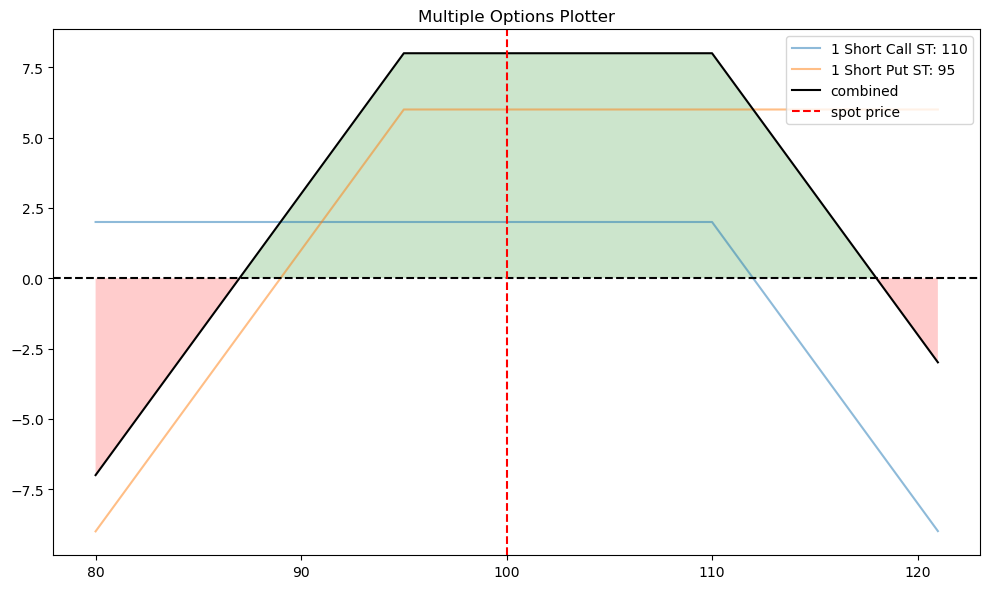

In [33]:
op_1 = {'op_type':'c','strike':110,'tr_type':'s','op_pr':2}
op_2 = {'op_type':'p', 'strike':95,'tr_type':'s','op_pr':6}
op.multi_plotter(spot = 100, op_list = [op_1, op_2])

### **Long Iron Condor**

- Un *iron condor* est une stratégie d'options composée de 2 *puts* (un long, un short) et de 2 *calls* (un long, un short) ainsi que de 4 prix d'exercice (*strikes*), ayant tous la même date d'échéance.

- Un *Long Iron Condor* est une stratégie d'options construite en utilisant quatre options ayant la même date d'échéance :

* Un *long put*
* Un *short put*
* Un *short call*
* Un *long call*

- Les *strikes* sont ordonnés comme suit : $K_1 < K_2 < K_3 < K_4$

où

* $K_1$ : *strike* du *long put*,
* $K_2$ : *strike* du *short put*,
* $K_3$ : *strike* du *short call*,
* $K_4$ : *strike* du *long call*.

- Le profit maximal est réalisé lorsque l'actif sous-jacent se termine entre les prix d'exercice centraux à l'échéance, lorsque la volatilité est faible.

- Votre configuration se compose de quatre jambes avec les strikes suivants : $K_1=205, K_2=210, K_3=215, K_4=220$

**Crédit net reçu : $(7,20 + 7,63) - (5,52 + 5,35) = 14,83 - 10,87 = \mathbf{3,96 \$}$.**

**Logique :** Vous encaissez ce crédit de 3,96$ en échange de l'engagement de couvrir les mouvements extrêmes au-delà de 205$ ou 220$.

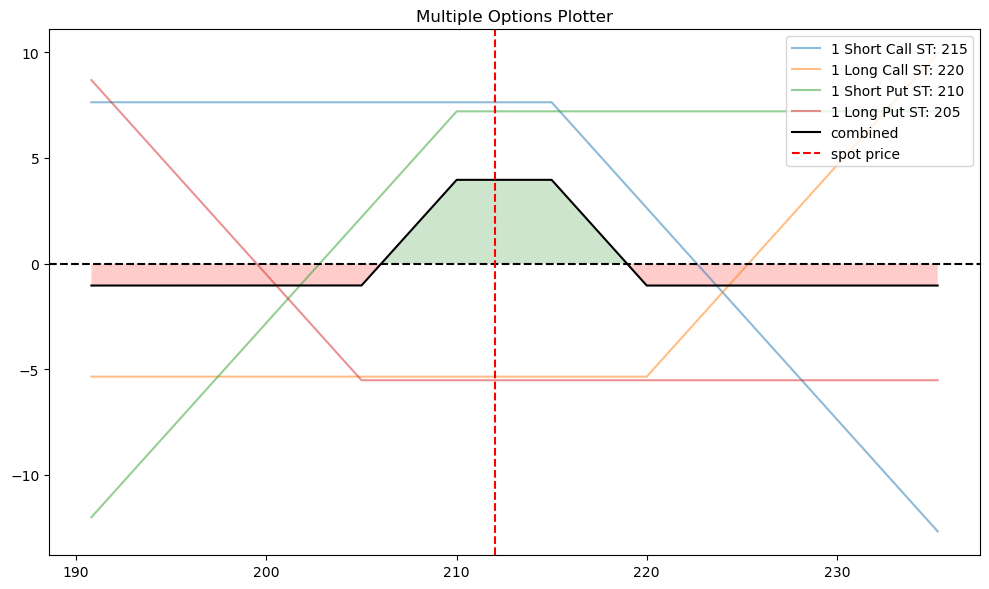

In [34]:
op1={'op_type': 'c', 'strike': 215, 'tr_type': 's', 'op_pr': 7.63}
op2={'op_type': 'c', 'strike': 220, 'tr_type': 'b', 'op_pr': 5.35}
op3={'op_type': 'p', 'strike': 210, 'tr_type': 's', 'op_pr': 7.20}
op4={'op_type': 'p', 'strike': 205, 'tr_type': 'b', 'op_pr': 5.52}

op_list=[op1, op2, op3, op4]
op.multi_plotter(spot=212,spot_range=10, op_list=op_list)

### **Long Butterfly**

- Un *butterfly* est une stratégie d'options composée d'un *long call* de *strike* $K_1$, de 2 *short calls* de *strike* $K_2$, et d'un *long call* de *strike* $K_3$, où $K_2 = (K_1 + K_3) / 2$.

- Le profit maximal est réalisé lorsque la volatilité future de l'actif sous-jacent est inférieure à la volatilité implicite actuelle.

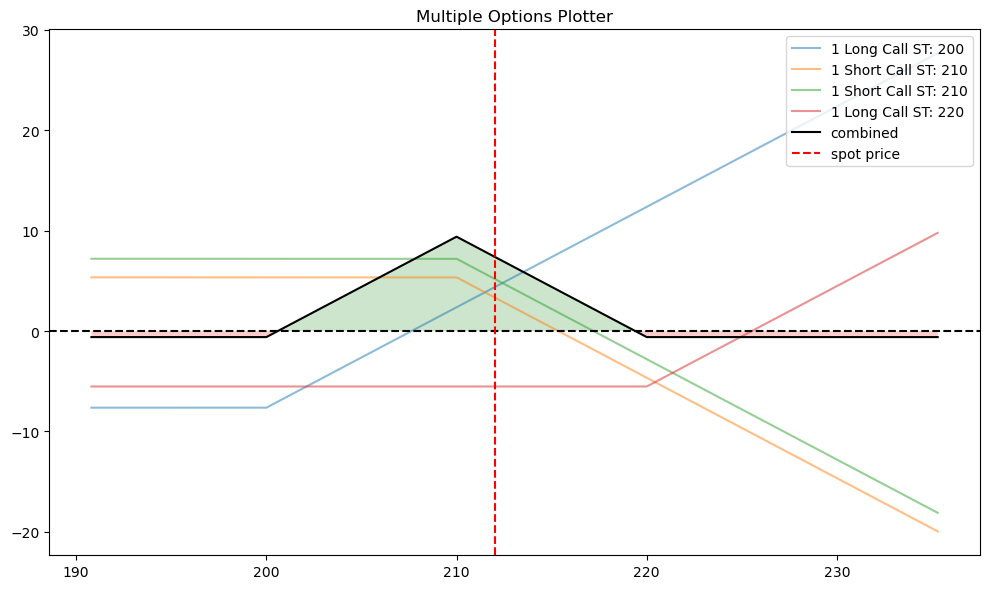

In [35]:
op1={'op_type': 'c', 'strike': 200, 'tr_type': 'b', 'op_pr': 7.63}
op2={'op_type': 'c', 'strike': 210, 'tr_type': 's', 'op_pr': 5.35}
op3={'op_type': 'c', 'strike': 210, 'tr_type': 's', 'op_pr': 7.20}
op4={'op_type': 'c', 'strike': 220, 'tr_type': 'b', 'op_pr': 5.52}

op_list=[op1, op2, op3, op4]
op.multi_plotter(spot=212,spot_range=10, op_list=op_list)

## VI - **Exemple de Projet**

Voici la traduction en français de votre texte :

* **Scraping de Yahoo Finance :**

Vous pouvez trouver les chaînes d'options en direct [ici](https://finance.yahoo.com/quote/%5EXSP/options?p=%5EXSP). L'idée est de scraper les enregistrements de transactions à haute fréquence afin de disposer de suffisamment de données historiques pour le *backtesting*. Vous pouvez utiliser le package Yahoo Finance en Python.

In [36]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

In [37]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [38]:
path_input_data = r'C:\Users\-yassi\-OneDrive\-Bureau\-MSc Financial Markets, Portfolio management\-Master 2 Finance Gestion de Portefeuille\-Produits dérivés'

In [39]:
underlyings_list = ['NVDA']

In [40]:
underlying_hist = yf.Tickers(underlyings_list).history(interval='1d')
underlying_hist = underlying_hist.stack(level=1).rename_axis(['Date','Ticker']).reset_index(level=1)
underlying_hist.reset_index(inplace=True)
underlying_hist.columns = underlying_hist.columns.str.lower()
underlying_hist.rename({'date': 'timestamp_etc', 'ticker': 'security_id'}, axis=1, inplace=True)
underlying_hist['timestamp_etc'] = pd.to_datetime(underlying_hist['timestamp_etc'])
underlying_hist.drop(['dividends','stock splits'],inplace=True,axis=1)
underlying_hist = underlying_hist.sort_values(by=['timestamp_etc'], ascending=True)
underlying_hist = underlying_hist.reset_index(drop=True)
underlying_hist['security_type'] = 'equity'

[*********************100%***********************]  1 of 1 completed


In [41]:
underlying_hist.head()

Price,timestamp_etc,security_id,close,high,low,open,volume,security_type
0,2026-06-10,NVDA,200.419998,207.220001,199.919998,204.429993,161746600,equity
1,2026-06-11,NVDA,204.869995,205.660004,199.539993,201.490005,158643200,equity
2,2026-06-12,NVDA,205.190002,207.070007,203.440002,204.860001,112001800,equity
3,2026-06-15,NVDA,212.449997,212.710007,208.339996,208.919998,149936700,equity
4,2026-06-16,NVDA,207.410004,211.490005,207.289993,211.179993,125694100,equity


In [42]:
np.max(underlying_hist.timestamp_etc)

Timestamp('2026-07-10 00:00:00')

In [43]:
np.min(underlying_hist.timestamp_etc)

Timestamp('2026-06-10 00:00:00')

In [44]:
def retrieve_options_chains(ticker):
    security = yf.Ticker(ticker)
    expirations = security.options
    chains = pd.DataFrame()
    for expiration in expirations:
        option = security.option_chain(expiration)
        calls = option.calls
        calls['type'] = 'call'
        puts = option.puts
        puts['type'] = 'put'
        chain = pd.concat([calls,puts])
        chain['expiration'] = ( pd.to_datetime(expiration) + pd.DateOffset(hours=23, minutes=59, seconds=59) )
        chains = pd.concat([chains,chain])
    chains.drop(['change','percentChange','contractSize'],inplace=True,axis=1)
    chains['days_to_expiration'] = ( chains['expiration'] - dt.datetime.today() ).dt.days + 1
    chains['mid'] = (chains['bid'] + chains['ask']) / 2 
    name_dict = {'contractSymbol': 'contract',
                 'lastTradeDate': 'last_trade_date_etc',
                 'lastPrice': 'last_price',
                 'openInterest': 'open_interest',
                 'impliedVolatility': 'implied_vol',
                 'inTheMoney': 'isITM',
                 'optionType': 'type',
                 'expiration': 'expiration_time_etc'}
    chains.rename(columns=name_dict, inplace=True)
    return(chains)

In [45]:
options = retrieve_options_chains('NVDA')
options

,contract,last_trade_date_etc,strike,last_price,bid,ask,volume,open_interest,implied_vol,isITM,currency,type,expiration_time_etc,days_to_expiration,mid
0,NVDA260710C00050000,2026-07-10 17:53:31+00:00,50.0,159.90,158.35,161.45,43.0,54.0,16.039067,True,USD,call,2026-07-10 23:59:59,1,159.900
1,NVDA260710C00055000,2026-07-10 17:53:31+00:00,55.0,155.00,153.45,156.55,47.0,39.0,15.214844,True,USD,call,2026-07-10 23:59:59,1,155.000
2,NVDA260710C00060000,2026-07-10 17:57:55+00:00,60.0,150.37,148.55,151.30,13.0,29.0,13.785158,True,USD,call,2026-07-10 23:59:59,1,149.925
3,NVDA260710C00065000,2026-07-10 17:53:08+00:00,65.0,145.02,143.65,146.40,19.0,163.0,7.375001,True,USD,call,2026-07-10 23:59:59,1,145.025
4,NVDA260710C00070000,2026-07-10 17:49:09+00:00,70.0,140.22,139.05,141.40,26.0,45.0,9.171879,True,USD,call,2026-07-10 23:59:59,1,140.225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,NVDA281215P00420000,2026-07-09 15:05:31+00:00,420.0,219.00,207.45,213.60,95.0,94.0,0.291816,True,USD,put,2028-12-15 23:59:59,890,210.525
72,NVDA281215P00430000,2026-07-09 17:45:38+00:00,430.0,226.95,217.30,222.85,214.0,207.0,0.284645,True,USD,put,2028-12-15 23:59:59,890,220.075
73,NVDA281215P00440000,2026-07-09 18:35:48+00:00,440.0,236.15,226.90,232.55,201.0,197.0,0.285011,True,USD,put,2028-12-15 23:59:59,890,229.725
74,NVDA281215P00450000,2026-07-09 18:02:04+00:00,450.0,246.74,235.70,242.10,301.0,0.0,0.281074,True,USD,put,2028-12-15 23:59:59,890,238.900


In [46]:
calls = options[options['type']=='call']
calls

,contract,last_trade_date_etc,strike,last_price,bid,ask,volume,open_interest,implied_vol,isITM,currency,type,expiration_time_etc,days_to_expiration,mid
0,NVDA260710C00050000,2026-07-10 17:53:31+00:00,50.0,159.90,158.35,161.45,43.0,54.0,16.039067,True,USD,call,2026-07-10 23:59:59,1,159.900
1,NVDA260710C00055000,2026-07-10 17:53:31+00:00,55.0,155.00,153.45,156.55,47.0,39.0,15.214844,True,USD,call,2026-07-10 23:59:59,1,155.000
2,NVDA260710C00060000,2026-07-10 17:57:55+00:00,60.0,150.37,148.55,151.30,13.0,29.0,13.785158,True,USD,call,2026-07-10 23:59:59,1,149.925
3,NVDA260710C00065000,2026-07-10 17:53:08+00:00,65.0,145.02,143.65,146.40,19.0,163.0,7.375001,True,USD,call,2026-07-10 23:59:59,1,145.025
4,NVDA260710C00070000,2026-07-10 17:49:09+00:00,70.0,140.22,139.05,141.40,26.0,45.0,9.171879,True,USD,call,2026-07-10 23:59:59,1,140.225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,NVDA281215C00420000,2026-07-10 16:23:50+00:00,420.0,19.90,19.00,20.25,14.0,1514.0,0.478078,False,USD,call,2028-12-15 23:59:59,890,19.625
72,NVDA281215C00430000,2026-07-09 18:41:58+00:00,430.0,17.25,18.40,19.40,21.0,295.0,0.478887,False,USD,call,2028-12-15 23:59:59,890,18.900
73,NVDA281215C00440000,2026-07-10 16:27:13+00:00,440.0,17.93,17.10,18.75,1.0,463.0,0.481084,False,USD,call,2028-12-15 23:59:59,890,17.925
74,NVDA281215C00450000,2026-07-10 17:29:20+00:00,450.0,17.05,16.85,17.45,67.0,6177.0,0.476812,False,USD,call,2028-12-15 23:59:59,890,17.150


In [47]:
calls.expiration_time_etc.unique()

<DatetimeArray>
['2026-07-10 23:59:59', '2026-07-13 23:59:59', '2026-07-15 23:59:59',
 '2026-07-17 23:59:59', '2026-07-20 23:59:59', '2026-07-22 23:59:59',
 '2026-07-24 23:59:59', '2026-07-31 23:59:59', '2026-08-07 23:59:59',
 '2026-08-14 23:59:59', '2026-08-21 23:59:59', '2026-09-18 23:59:59',
 '2026-10-16 23:59:59', '2026-11-20 23:59:59', '2026-12-18 23:59:59',
 '2027-01-15 23:59:59', '2027-02-19 23:59:59', '2027-03-19 23:59:59',
 '2027-06-17 23:59:59', '2027-09-17 23:59:59', '2027-12-17 23:59:59',
 '2028-01-21 23:59:59', '2028-06-16 23:59:59', '2028-12-15 23:59:59']
Length: 24, dtype: datetime64[ns]

<Axes: xlabel='strike'>

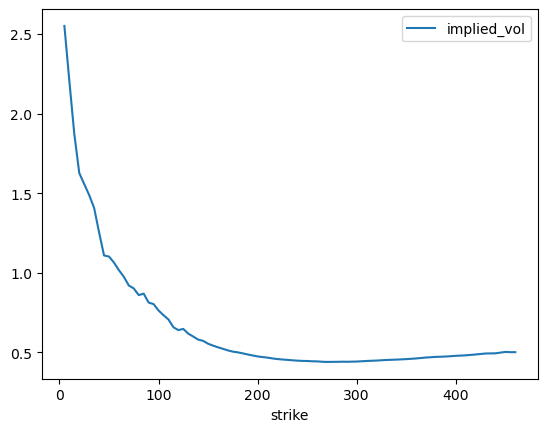

In [48]:
calls_at_expiry = calls[calls['expiration_time_etc']=='2027-01-15 23:59:59']
filtered_calls_at_expiry = calls_at_expiry[calls_at_expiry['implied_vol'] >= 0.001]
filtered_calls_at_expiry[['strike','implied_vol']].set_index('strike').plot()

<Axes: xlabel='expiration_time_etc'>

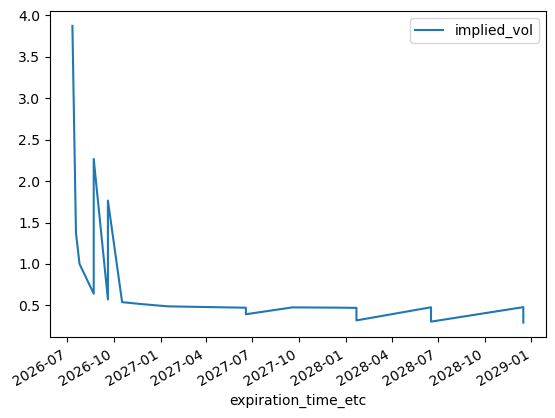

In [49]:
calls_at_strike = options[options['strike'] == 420]
filtered_calls_at_strike = calls_at_strike[calls_at_strike['implied_vol'] >= 0.001] 
filtered_calls_at_strike[['expiration_time_etc','implied_vol']].set_index('expiration_time_etc').plot()

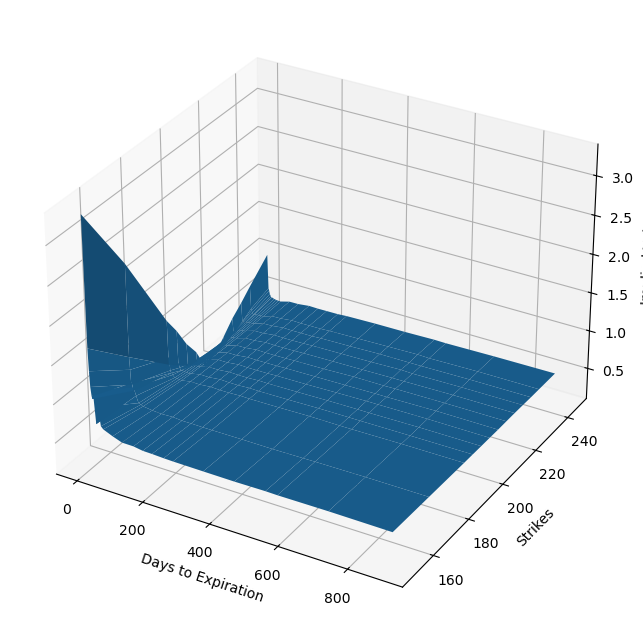

In [50]:
surface = (calls[['days_to_expiration', 'strike', 'implied_vol']].pivot_table(values='implied_vol', index='strike', columns='days_to_expiration').dropna())
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
x, y, z = surface.columns.values, surface.index.values, surface.values
X, Y = np.meshgrid(x, y)
ax.set_xlabel('Days to Expiration')
ax.set_ylabel('Strikes')
ax.set_zlabel('Implied Vol')
ax.plot_surface(X, Y, z)

In [51]:
import plotly.graph_objects as go

# 1. Préparation des données (Votre code d'origine, qui est parfait)
surface = (options[['days_to_expiration', 'strike', 'implied_vol']]
           .pivot_table(values='implied_vol', index='strike', columns='days_to_expiration')
           .dropna())

# 2. Extraction des axes
x = surface.columns.values  # Days to Expiration
y = surface.index.values    # Strikes
z = surface.values          # Implied Volatility

# 3. Création de la figure 3D dynamique avec Plotly
fig = go.Figure(data=[go.Surface(z=z, x=x, y=y, colorscale='Viridis')])

# 4. Paramétrage de l'affichage (Mise en page)
fig.update_layout(
    title="Surface de Volatilité Interactive (NVDA)",
    autosize=False,
    width=900, 
    height=800,
    scene=dict(
        xaxis_title='Days to Expiration (DTE)',
        yaxis_title='Strike ($)',
        zaxis_title='Implied Volatility (IV)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2) # Angle de vue initial de la caméra
        )
    )
)

# 5. Affichage (Ouvre une page HTML interactive ou s'affiche dans Jupyter)
fig.show()

technique de smothing, d'interpolation : ça va rendre ma backtest plus robust

Backtester avec un contrat, une maturité